#  Analyse de Sentiment — Avis Clients Bancaires
**Objectif :** Explorer et comprendre le dataset de sentiments financiers.

In [1]:
#  Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk

# Télécharger les ressources NLTK
nltk.download('stopwords')
nltk.download('punkt')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Bibliothèques importées avec succès !")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\emman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\emman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


 Bibliothèques importées avec succès !


In [2]:
#  Chargement du dataset
df = pd.read_csv(r'C:\Users\emman\Documents\Portfolio\sentiment-analysis-banking\data\data.csv')

print(f"✅ Dataset chargé !")
print(f"📊 Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"\n📋 Colonnes : {list(df.columns)}")
print(f"\n👀 Aperçu :")
df.head()

✅ Dataset chargé !
📊 Dimensions : 5842 lignes x 2 colonnes

📋 Colonnes : ['Sentence', 'Sentiment']

👀 Aperçu :


,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [3]:
# 📊 Informations générales
print("ℹ️ Informations générales :")
print(df.info())

print("\n📊 Distribution des sentiments :")
print(df['Sentiment'].value_counts())

print("\n📈 Pourcentages :")
print(df['Sentiment'].value_counts(normalize=True).mul(100).round(2))

ℹ️ Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sentence   5842 non-null   str  
 1   Sentiment  5842 non-null   str  
dtypes: str(2)
memory usage: 801.8 KB
None

📊 Distribution des sentiments :
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

📈 Pourcentages :
Sentiment
neutral     53.58
positive    31.70
negative    14.72
Name: proportion, dtype: float64


C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2189818172.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2189818172.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('../reports/01_distribution_sentiments.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


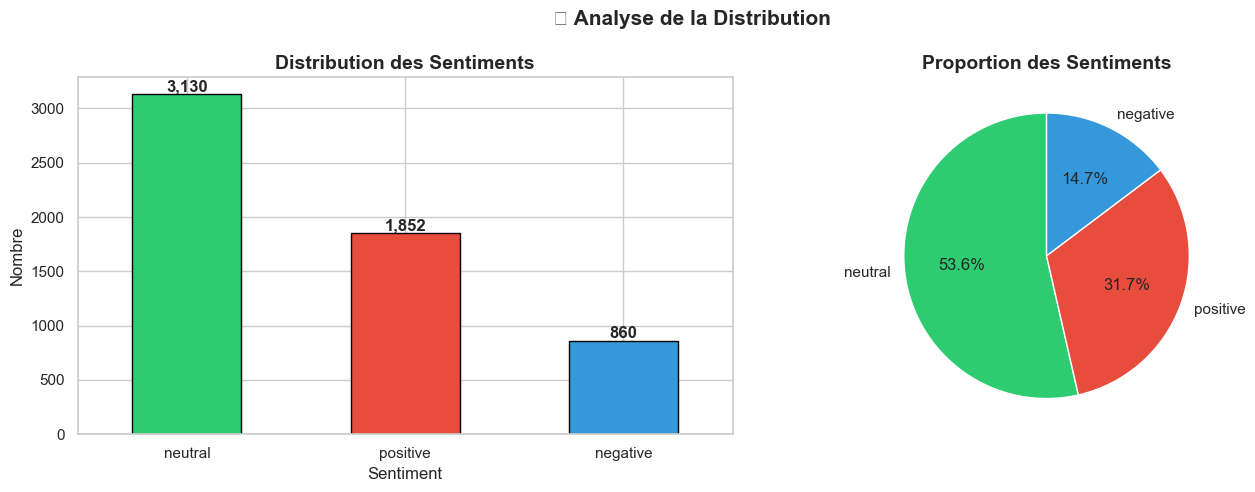

✅ Graphique sauvegardé !


In [4]:
# 📊 Distribution des sentiments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

couleurs = ['#2ecc71', '#e74c3c', '#3498db']
sentiments = df['Sentiment'].value_counts()

# --- Graphique 1 : Barres ---
sentiments.plot(
    kind='bar',
    ax=axes[0],
    color=couleurs,
    edgecolor='black'
)
axes[0].set_title('Distribution des Sentiments',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Nombre')
axes[0].set_xticklabels(
    sentiments.index, rotation=0
)
for i, v in enumerate(sentiments):
    axes[0].text(i, v + 30, f'{v:,}',
                 ha='center', fontweight='bold')

# --- Graphique 2 : Camembert ---
axes[1].pie(
    sentiments,
    labels=sentiments.index,
    colors=couleurs,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proportion des Sentiments',
                  fontsize=14, fontweight='bold')

plt.suptitle('📊 Analyse de la Distribution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_distribution_sentiments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2801296924.py:62: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2801296924.py:63: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.savefig('../reports/02_longueur_textes.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


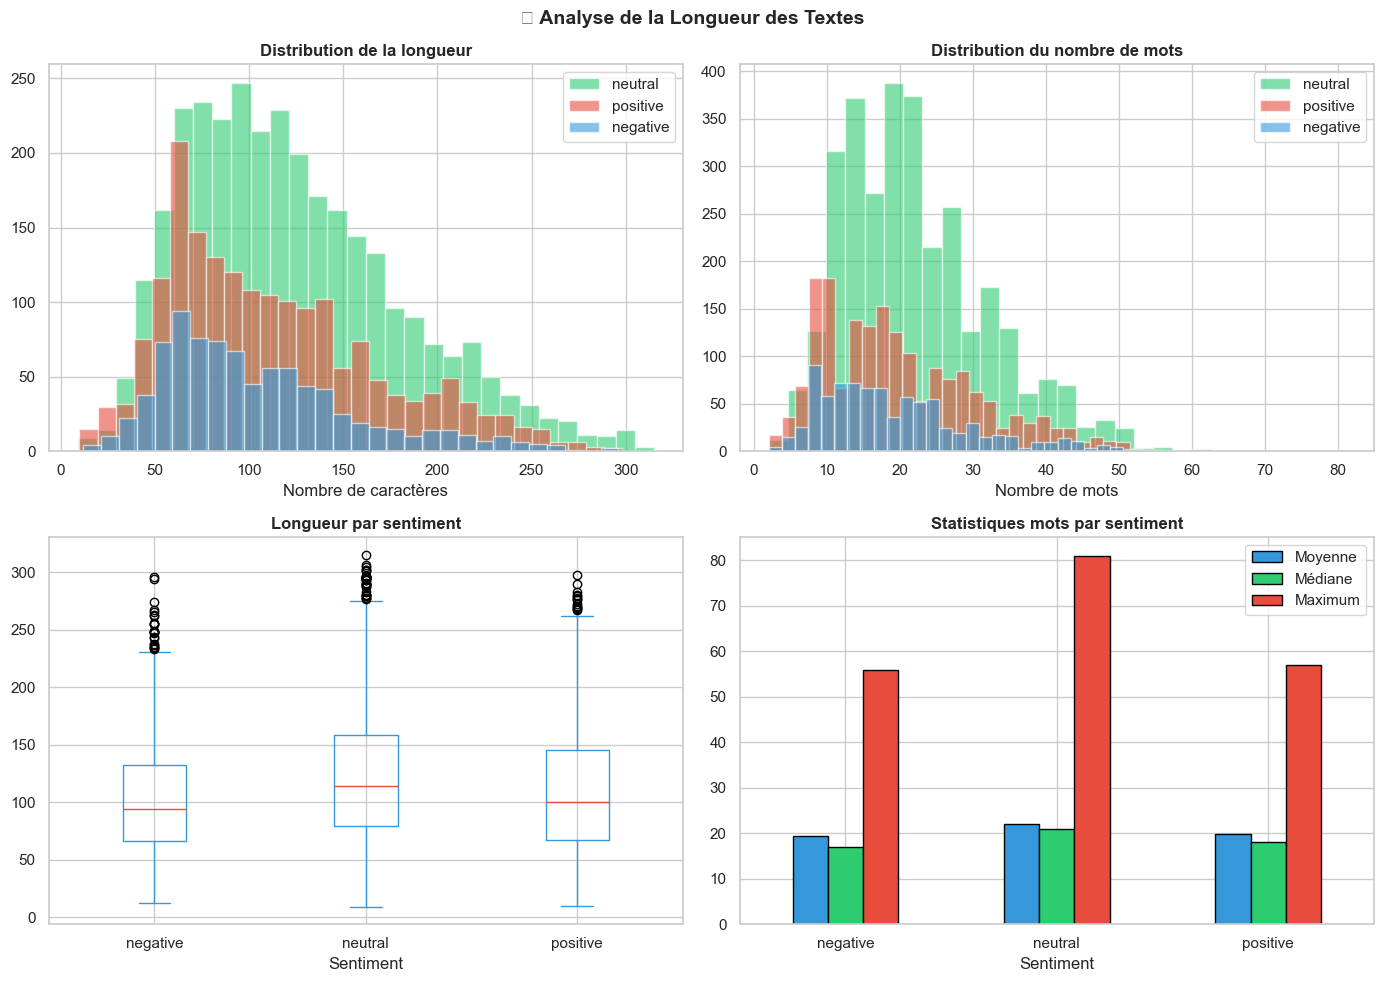

✅ Graphique sauvegardé !

📊 Statistiques :
           mean  median  max
Sentiment                   
negative   19.3    17.0   56
neutral    22.1    21.0   81
positive   19.9    18.0   57


In [5]:
# 📏 Analyse de la longueur des phrases
df['text_length']  = df['Sentence'].str.len()
df['word_count']   = df['Sentence'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Graphique 1 : Longueur par sentiment ---
for sentiment, couleur in zip(
    ['neutral', 'positive', 'negative'],
    ['#2ecc71', '#e74c3c', '#3498db']
):
    data = df[df['Sentiment'] == sentiment]['text_length']
    axes[0,0].hist(data, bins=30, alpha=0.6,
                   color=couleur, label=sentiment)
axes[0,0].set_title('Distribution de la longueur',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Nombre de caractères')
axes[0,0].legend()

# --- Graphique 2 : Nombre de mots ---
for sentiment, couleur in zip(
    ['neutral', 'positive', 'negative'],
    ['#2ecc71', '#e74c3c', '#3498db']
):
    data = df[df['Sentiment'] == sentiment]['word_count']
    axes[0,1].hist(data, bins=30, alpha=0.6,
                   color=couleur, label=sentiment)
axes[0,1].set_title('Distribution du nombre de mots',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Nombre de mots')
axes[0,1].legend()

# --- Graphique 3 : Boxplot longueur ---
df.boxplot(column='text_length', by='Sentiment',
           ax=axes[1,0],
           color=dict(boxes='#3498db',
                      whiskers='#3498db',
                      medians='#e74c3c',
                      caps='#3498db'))
axes[1,0].set_title('Longueur par sentiment',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Sentiment')
plt.sca(axes[1,0])
plt.xticks(rotation=0)

# --- Graphique 4 : Statistiques ---
stats = df.groupby('Sentiment')['word_count'].agg(
    ['mean', 'median', 'max']
).round(1)
stats.plot(kind='bar', ax=axes[1,1],
           color=['#3498db', '#2ecc71', '#e74c3c'],
           edgecolor='black')
axes[1,1].set_title('Statistiques mots par sentiment',
                    fontsize=12, fontweight='bold')
axes[1,1].set_xticklabels(
    stats.index, rotation=0
)
axes[1,1].legend(['Moyenne', 'Médiane', 'Maximum'])

plt.suptitle('📏 Analyse de la Longueur des Textes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_longueur_textes.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé !")
print(f"\n📊 Statistiques :")
print(stats)

C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2857037867.py:50: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2857037867.py:50: UserWarning: Glyph 128528 (\N{NEUTRAL FACE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2857037867.py:50: UserWarning: Glyph 128545 (\N{POUTING FACE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2857037867.py:50: UserWarning: Glyph 9729 (\N{CLOUD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2857037867.py:50: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_4916\2857037867.py:51: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  plt.savefig('../re

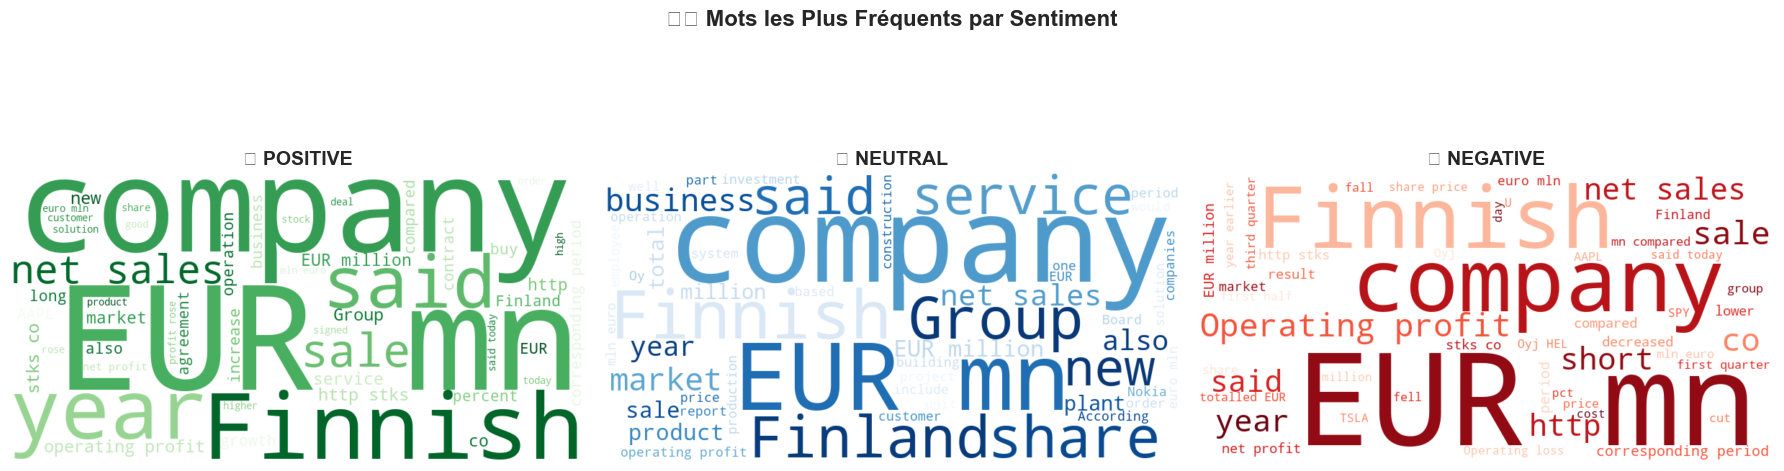

✅ WordCloud sauvegardé !


In [6]:
# ☁️ WordCloud par sentiment
from wordcloud import WordCloud
from nltk.corpus import stopwords

# 1. Créer la liste des mots à ignorer
stop_words = set(stopwords.words('english'))

# 2. Créer 3 cases côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 3. Associer chaque sentiment à une couleur et une case
sentiments_config = [
    ('positive', '#2ecc71', axes[0]),
    ('neutral',  '#3498db', axes[1]),
    ('negative', '#e74c3c', axes[2])
]

# 4. Boucle sur chaque sentiment
for sentiment, couleur, ax in sentiments_config:

    # Coller tous les textes du sentiment ensemble
    textes = ' '.join(
        df[df['Sentiment'] == sentiment]['Sentence']
    )

    # Générer le nuage de mots
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words,
        colormap='Greens' if sentiment == 'positive'
                 else 'Blues' if sentiment == 'neutral'
                 else 'Reds',
        max_words=50
    ).generate(textes)

    # Afficher le nuage dans sa case
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(
        '😊 POSITIVE' if sentiment == 'positive'
        else '😐 NEUTRAL' if sentiment == 'neutral'
        else '😡 NEGATIVE',
        fontsize=14, fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('☁️ Mots les Plus Fréquents par Sentiment',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_wordcloud_sentiments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ WordCloud sauvegardé !")